# Predictive Text Generation using GRU

## Installing Packages

In [1]:
%pip install numpy keras tensorflow scikit-learn matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Importing Libraries

In [2]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

2025-06-16 21:37:01.948471: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 21:37:02.205405: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 21:37:02.367265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750109822.593413    4053 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750109822.721075    4053 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750109823.340684    4053 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Example data preparation (replace with your actual data)

In [3]:
t = np.linspace(0, 100, 1000)
data = np.sin(t)
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1)).flatten()

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30  # Tuned: sequence length
X, y = create_sequences(data, seq_length)
X = X[..., np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## Build GRU model with tuned hyperparameters

In [4]:
gru_model = Sequential([
    GRU(64, input_shape=(seq_length, 1), return_sequences=True),  # Tuned: units, return_sequences
    Dropout(0.2),  # Tuned: dropout rate
    GRU(32),  # Tuned: stacked GRU layer
    Dense(16, activation='relu'),  # Tuned: dense layer size and activation
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)  # Tuned: learning rate
gru_model.compile(optimizer=optimizer, loss='mse')

2025-06-16 21:37:08.982265: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Training the model

In [5]:
history = gru_model.fit(
    X_train, y_train,
    epochs=40,             # Tuned: number of epochs
    batch_size=32,         # Tuned: batch size
    validation_split=0.1,
    verbose=1
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.1425 - val_loss: 0.0247
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0209 - val_loss: 0.0106
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0111 - val_loss: 0.0053
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0063 - val_loss: 0.0017
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0032 - val_loss: 2.3465e-04
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0032 - val_loss: 3.2736e-04
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017 - val_loss: 1.8266e-04
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0011 - val_loss: 3.8920e-05
Epoch 9/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 9.8330e-04 - val_loss: 5.9206e-05
Epoch 10/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.3014e-04 - val_loss: 1.1098e-04
Epoch 11/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.8862e-04 - val_loss: 2.0198e-04
Epoch 12/40
22/22 ━━━━━

## Evaluation


In [6]:
test_loss = gru_model.evaluate(X_test, y_test)
print(f"GRU Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.8314e-05 
GRU Test Loss: 0.0001


## Plot training/validation loss

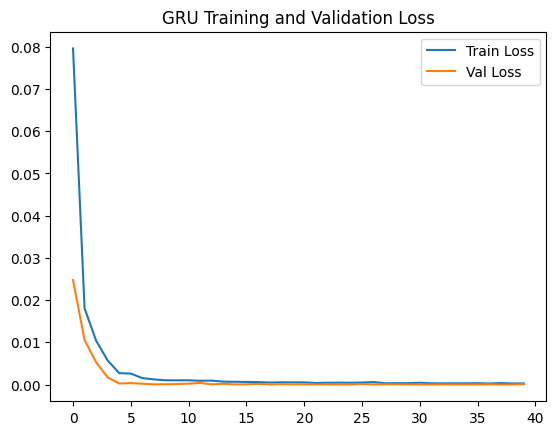

In [7]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('GRU Training and Validation Loss')
plt.show()